# Stacking Regression

## Import Required Libraries

In [1]:
import joblib
import pandas as pd
from sklearn.model_selection import train_test_split
import os
from sklearn.linear_model import Lasso, Ridge, LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, StackingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import matplotlib.pyplot as plt
from xgboost import XGBRegressor

## Load Engineered Features

In [2]:
df = pd.read_csv('../feature_engineering.csv')

In [3]:
feature_columns = [
    'word_count', 'average_word_length', 'percent_complex_words', 'percent_difficult_words', 'sentence_count', 'syllables_per_word',
    'polysyllable_count', 'flesch_reading_ease', 'automated_readability_index',
    'dale_chall_readability_score', 'difficult_words', 'linsear_write_formula',
    'spache_readability', 'reading_time'
]

X = df[feature_columns]
y = df['fk_estimated_uk_age_num']

## Model Training and Test Split

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=456
)

## Hyperparameter Tuning

In [ ]:
base_learners = [
    ('lr', LinearRegression()),
    ('ridge', Ridge(alpha=np.float64(0.11), max_iter=20000, random_state=4)),
    ('rf', RandomForestRegressor(max_depth=15, max_features='sqrt', min_samples_leaf=1, 
                                 min_samples_split=5, n_estimators=100, random_state=42)),
    ('xgb', XGBRegressor(n_estimators=1000, max_depth=7, learning_rate=0.1, subsample=0.7, 
                         colsample_bytree=0.8, random_state=456, n_jobs=-1))
]

# Meta-learner: use a simple linear regression
meta_learner = LinearRegression()

# Stacking regressor
stacking_reg = StackingRegressor(estimators=base_learners, final_estimator=meta_learner, cv=5)

# Train the stacking regressor
stacking_reg.fit(X_train, y_train)



StackingRegressor(cv=5,
                  estimators=[('lr', LinearRegression()),
                              ('ridge',
                               Ridge(alpha=np.float64(0.11), max_iter=20000,
                                     random_state=4)),
                              ('rf',
                               RandomForestRegressor(max_depth=15,
                                                     max_features='sqrt',
                                                     min_samples_split=5,
                                                     random_state=42)),
                              ('xgb',
                               XGBRegressor(base_score=None, booster=None,
                                            callbacks=None,
                                            colsample_bylevel=None,
                                            colsample_bynode=None,
                                            colsample_b...
                                            grow_policy=None,
                                            importance_type=None,
                                            interaction_constraints=None,
                                            learning_rate=0.1, max_bin=None,
                                            max_cat_threshold=None,
                                            max_cat_to_onehot=None,
                                            max_delta_step=None, max_depth=7,
                                            max_leaves=None,
                                            min_child_weight=None, missing=nan,
                                            monotone_constraints=None,
                                            multi_strategy=None,
                                            n_estimators=1000, n_jobs=-1,
                                            num_parallel_tree=None, ...))],
                  final_estimator=LinearRegression())

## Save the Trained Model

In [6]:
joblib.dump(stacking_reg, '../../models/stacking_regressor.joblib')

['../../models/stacking_regressor.joblib']

## Evaluate Results

In [7]:
y_pred = stacking_reg.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = mse ** 0.5
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print(f"R^2 Score: {r2:.2f}")

y_train_pred = stacking_reg.predict(X_train)

mae_train = mean_absolute_error(y_train, y_train_pred)
r2_train = r2_score(y_train, y_train_pred)

print(f"Train MAE: {mae_train:.2f}, Train R^2: {r2_train:.2f}")
print(f"Test MAE: {mae:.2f}, Test R^2: {r2:.2f}")

MAE: 0.24518106472777756
MSE: 0.08287360027765309
RMSE: 0.2878777523145078
R^2 Score: 1.00
Train MAE: 0.24, Train R^2: 1.00
Test MAE: 0.25, Test R^2: 1.00


In [8]:
results = {
    'Model': 'Stacking Regressor',
    'MAE': mae,
    'MSE': mse,
    'RMSE': rmse,
    'R2': r2,
    'Params': str(stacking_reg.get_params()),
    'Notes': ''
}

In [9]:
results_file = '../all_model_results.csv'

# Turn the results dict into a DataFrame row
df_result = pd.DataFrame([results])

# If file exists, append without headers; else, create with headers
if os.path.isfile(results_file):
    df_result.to_csv(results_file, mode='a', header=False, index=False)
else:
    df_result.to_csv(results_file, index=False)

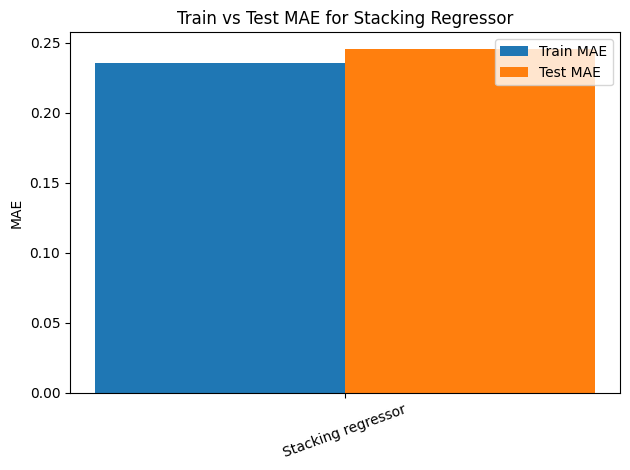

In [10]:
import matplotlib.pyplot as plt

# Visualize train vs test MAE for the Stacking model

models = ['Stacking regressor']
train_mae = [mae_train]
test_mae = [mae]

x = range(len(models))
plt.bar(x, train_mae, width=0.4, label='Train MAE')
plt.bar([i + 0.4 for i in x], test_mae, width=0.4, label='Test MAE')

plt.xticks([i + 0.2 for i in x], models, rotation=20)
plt.ylabel('MAE')
plt.title('Train vs Test MAE for Stacking Regressor')
plt.legend()
plt.tight_layout()
plt.show()

## Feature Importance Visualisation

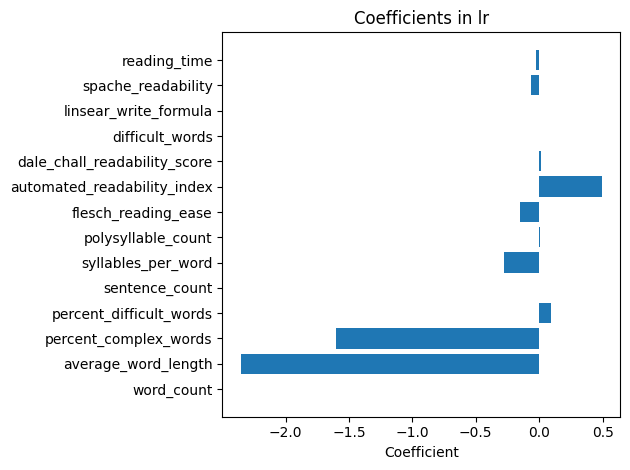

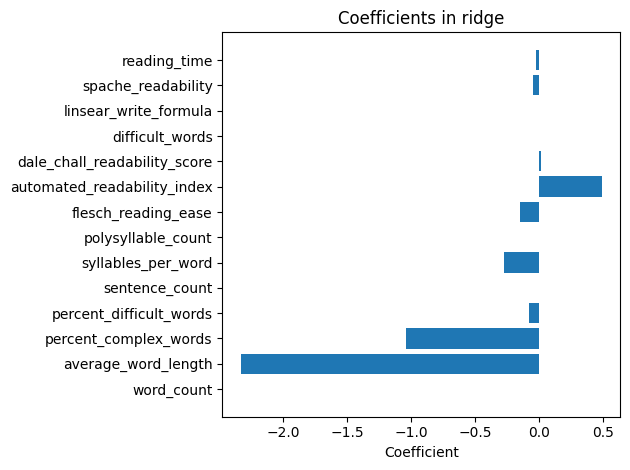

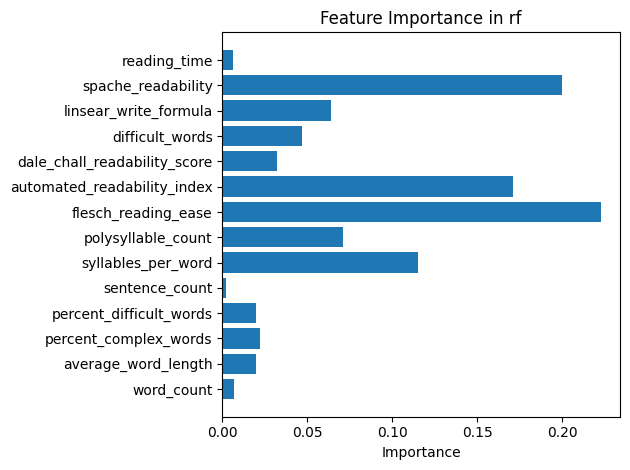

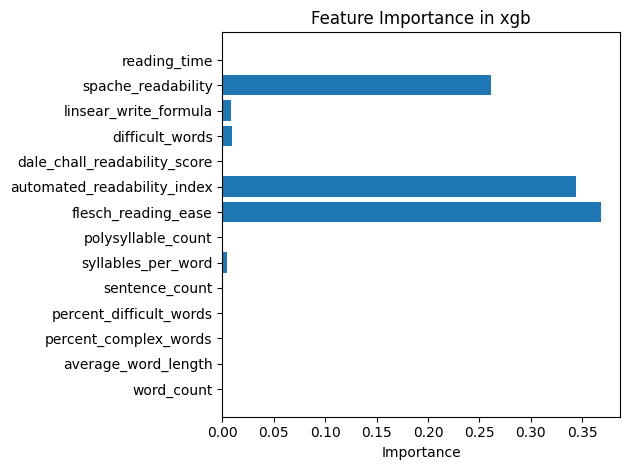

In [11]:
for name, model in stacking_reg.named_estimators_.items():
    plt.figure()
    if hasattr(model, "feature_importances_"):
        plt.barh(feature_columns, model.feature_importances_)
        plt.xlabel("Importance")
        plt.title(f"Feature Importance in {name}")
    elif hasattr(model, "coef_"):
        plt.barh(feature_columns, model.coef_)
        plt.xlabel("Coefficient")
        plt.title(f"Coefficients in {name}")
    else:
        plt.text(0.5, 0.5, f"No importances or coefficients for {name}", ha='center')
        plt.title(f"{name} (No importances or coefficients)")
    plt.tight_layout()
    plt.show()

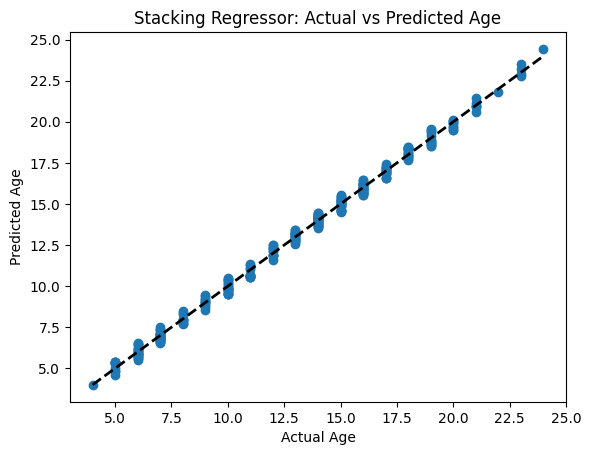

In [12]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred)
plt.xlabel("Actual Age")
plt.ylabel("Predicted Age")
plt.title("Stacking Regressor: Actual vs Predicted Age")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2)
plt.show()